# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + minmax scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('hotels.csv')


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [3]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


I notice that we have a good spread of categorical and numeric variables. I also notice that the column lead_time has a large standard deviation (106.86). That's a very wide spread, so it could be significant. There doesn't appear to be too many missing values other than the company column, so we may have to just drop that one as there are less than 7,000 of the rows with an actual value out of the over 119,000. For agent, there are also a good amount of missing values (over 16,000), so that would be fine to drop too.

In [5]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
prevalence = df['is_canceled'].mean()
print(f'Prevalence of cancellations: {prevalence}')

Prevalence of cancellations: 0.37041628277075134


This problem seems like it will be somewhat reasonable to solve this problem because the prevalence isn't too high or too low. It's slightly lower than a perfect 50%, but it's a reasonable amount of prevalence to try to predict and not have to stratify as heavily and such.

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [6]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# Drop company (over 90% of the values are missing)
df = df.drop(columns=['company'])

# Drop agent
df = df.drop(columns=['agent'])

In [8]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

# Drop reservation_status and reservation_status_date because reservation_status is basically directly telling us the target variable
# Reservation status date is also a problem because it's the date that the status was updated, which would be for
# checkouts, cancellations, or no-shows, making it also a direct leak of sorts
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

# Drop missing rows because it won't be able to deal with them in the model(s)
df = df.dropna()

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [9]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

In [18]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

CATEGORICAL = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel',
               'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
NUMERIC     = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
               'stays_in_week_nights', 'adults', 'children', 'babies']
TARGET      = 'is_canceled'

X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]

In [19]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 100, stratify = y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

percent_positive_train = y_train.mean() * 100
print(f"Train positive class: {percent_positive_train}%")

percent_positive_test = y_test.mean() * 100
print(f"Test positive class: {percent_positive_test}%")

Train: 95118 rows | Test: 23780 rows
Train positive class: 37.134927143127484%
Test positive class: 37.136248948696384%


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

In [20]:
# Model 1 - Baseline Logistic Regression
preprocess1 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # numerics passed through unchanged
])

pipe1 = Pipeline(steps = [
    ('prep',  preprocess1),
    ('model', LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = 100))
])

# Fit data
pipe1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

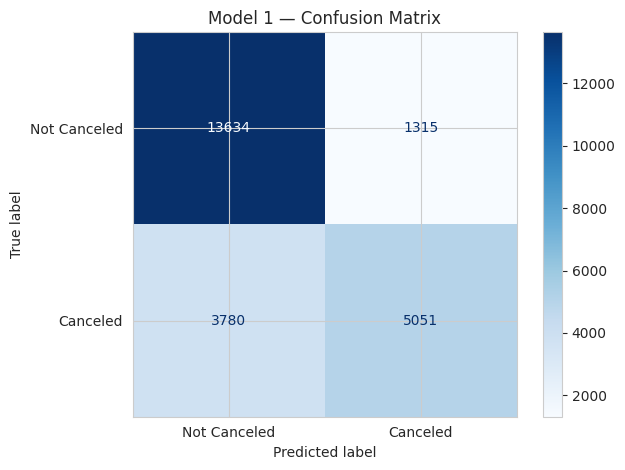

              precision    recall  f1-score   support

Not Canceled       0.78      0.91      0.84     14949
    Canceled       0.79      0.57      0.66      8831

    accuracy                           0.79     23780
   macro avg       0.79      0.74      0.75     23780
weighted avg       0.79      0.79      0.78     23780



In [21]:
# Predict using model 1
y_pred1 = pipe1.predict(X_test)
cm1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels = ['Not Canceled', 'Canceled'])
disp1.plot(cmap = 'Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred1, target_names = ['Not Canceled', 'Canceled']))

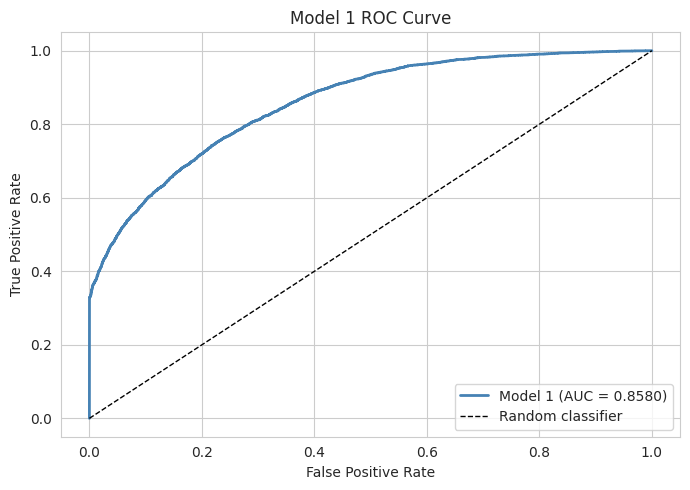

Model 1 ROC-AUC: 0.858040354606485


In [22]:
# Model 1 Evaluation with ROC AUC Score

y_proba_m1 = pipe1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(fpr_m1, tpr_m1, lw = 2, color = 'steelblue', label = f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw = 1, label = 'Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1}")

Given the goal of the assignment, this model performs okay, but definitely not great because even small discrepencies (anything over like 5-10%) will make it so we are losing money still and not really solving the problem. We get the classification of canceled correct about 57% of the time, which is pretty bad as it's about the same as flipping a coin.
The ROC/AUC of 0.86 isn't bad as it means there's some amount of predictive power, but some things like the threshold might be too weak for this classification. The even more costly error is the 43% of the customers that do actually cancel, but we don't think they will. This means we are completely leaving the rooms they booked empty, losing out on a ton of money.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [34]:
# Model 2
preprocess2 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC)
])

pipe2 = Pipeline(steps = [
    ('prep', preprocess2),
    ('model', LogisticRegression(solver = 'saga', penalty = 'l2', C = 0.1, max_iter = 1000, random_state = 100)) # use saga since this dataset is quite large (over 100k rows, so it would make sense to try this rather than liblinear)
])

pipe2.fit(X_train, y_train)

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

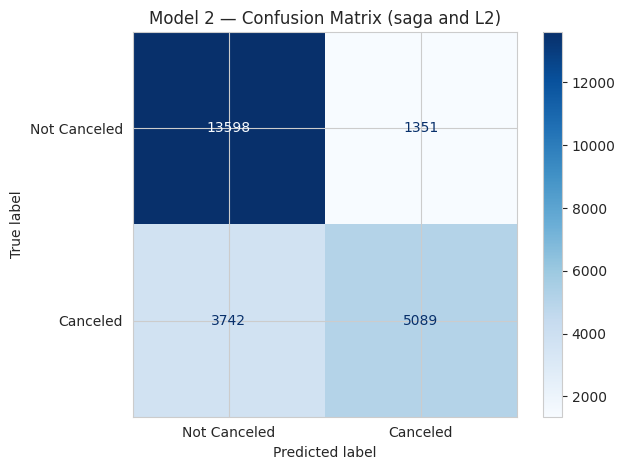

              precision    recall  f1-score   support

Not Canceled       0.78      0.91      0.84     14949
    Canceled       0.79      0.58      0.67      8831

    accuracy                           0.79     23780
   macro avg       0.79      0.74      0.75     23780
weighted avg       0.79      0.79      0.78     23780



In [35]:
# Evaluate Model 2
y_pred2 = pipe2.predict(X_test)
y_prob2 = pipe2.predict_proba(X_test)[:, 1]

cm2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels=['Not Canceled', 'Canceled'])
disp2.plot(cmap = 'Blues')
plt.title('Model 2 — Confusion Matrix (saga and L2)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred2, target_names = ['Not Canceled', 'Canceled']))

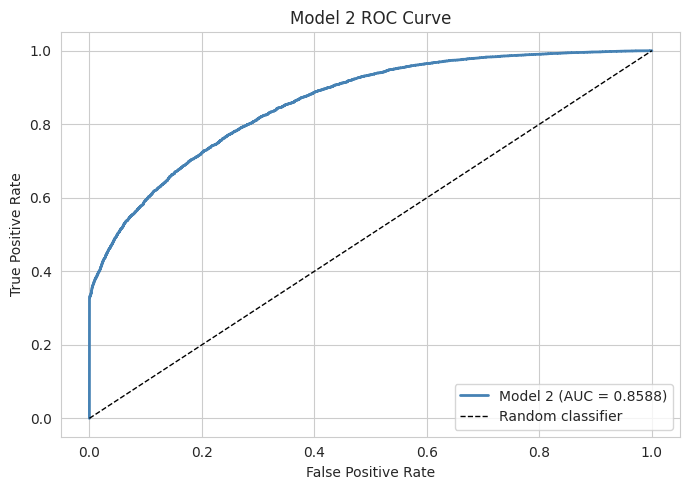

Model 2 ROC-AUC: 0.858826063043821


In [36]:
# Model 2 Evaluation with ROC AUC Score

y_proba_m2 = pipe2.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(fpr_m2, tpr_m2, lw = 2, color = 'steelblue', label = f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw = 1, label = 'Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2}")

The model appears to have *slightly* improved, but not by much. The recall for canceled went up by 0.01 from the change to saga and L2 as well as setting C to 0.1 rather than the default of 1. Other than that, the models appear to be nearly identical. The ROC/AUC value went up by 0.0008, but that's it. Again, technically improved the model, but not noticably.

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [56]:
# Model 3 - Balanced Class Weights and Cross-Validation

preprocess3 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC)
])

pipe3 = Pipeline(steps = [
    ('prep', preprocess3),
    ('model', LogisticRegression(solver = 'saga', penalty = 'l2', C = 0.1, class_weight = 'balanced', max_iter = 1000, random_state = 100)) # use saga since this dataset is quite large (over 100k rows, so it would make sense to try this rather than liblinear)
])

pipe3.fit(X_train, y_train)

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avo

ROC-AUC: 0.8538186737464162  ± 0.0019  | folds: [0.8515 0.8555 0.8566 0.8533 0.8522]
F1: 0.6511528662754618  ± 0.0032  | folds: [0.6483 0.6526 0.6562 0.6471 0.6515]


/tmp/ipykernel_3671/996734955.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


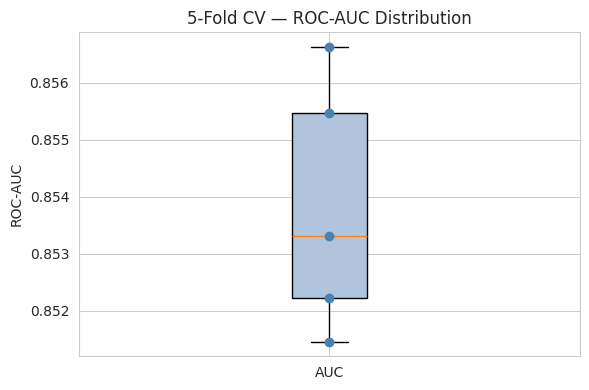

In [ ]:
# Cross Validation

cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 100)

cv_auc = cross_val_score(pipe3, X_train, y_train, cv = cv, scoring = 'roc_auc')
cv_f1 = cross_val_score(pipe3, X_train, y_train, cv = cv, scoring = 'f1')

print(f'ROC-AUC: {cv_auc.mean()}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}')
print(f'F1: {cv_f1.mean()}  ± {cv_f1.std():.4f}  | folds: {np.round(cv_f1, 4)}')

# Box-plot of fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*len(cv_auc), cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

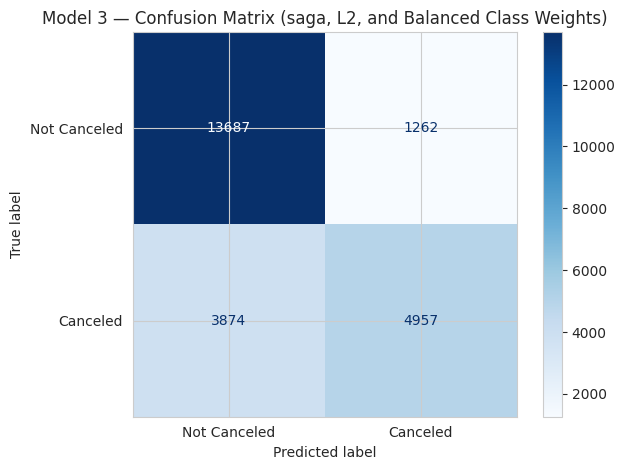

              precision    recall  f1-score   support

Not Canceled       0.78      0.92      0.84     14949
    Canceled       0.80      0.56      0.66      8831

    accuracy                           0.78     23780
   macro avg       0.79      0.74      0.75     23780
weighted avg       0.79      0.78      0.77     23780



In [54]:
# Evaluate with predictions and Confusion Matrix

y_pred3 = pipe3.predict(X_test)
y_prob3 = pipe3.predict_proba(X_test)[:, 1]

cm3 = confusion_matrix(y_test, y_pred3)
disp3 = ConfusionMatrixDisplay(confusion_matrix = cm3, display_labels=['Not Canceled', 'Canceled'])
disp3.plot(cmap = 'Blues')
plt.title('Model 3 — Confusion Matrix (saga, L2, and Balanced Class Weights)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred3, target_names = ['Not Canceled', 'Canceled']))

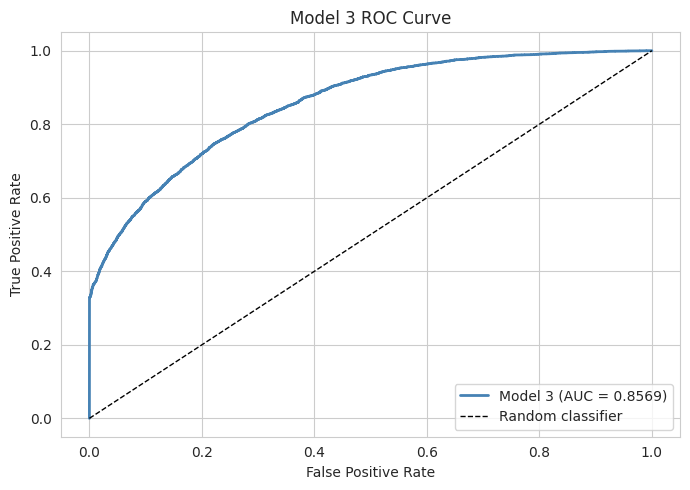

Model 3 ROC-AUC: 0.8568870429418125


In [55]:
# Model 3 Evaluation with ROC AUC Score

y_proba_m3 = pipe3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(fpr_m3, tpr_m3, lw = 2, color = 'steelblue', label = f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw = 1, label = 'Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3}")

Changing the folds from 5 to 10 doesn't really appear to make the AUC change much as it stays around 0.8575 both times (5 and 10 folds).

And removing balanced class weights makes the recall of canceled class decently drop from 0.70 to 0.56.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)


The model that worked best is the third model with cross validation and balanced class weights. I believe this to be the case because the target variable of whether or not the customer canceled isn't perfectly weighted 50/50, so adding a balance between these sides already makes it much better. And adding cross-validation on top of this makes it even better as it improves connsistency. I would recommend we proceed by using the third model, and even continue to test further on other methods of regression and tests to make sure we can get the best possible model because of how sensitive slight changes in the data can be due to the sheer amount of clients in the dataset and the massive amount of money we're considering here. Given the large dataset and the significant financial impact mistakes like false positives and false negatives can have on business, I recommend we push this to its limits to make sure we can gain as much revenue/profit as possible without draining too many resources on this either.


### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---